# Exploratory Data Analysis

Charge `data/processed/real_clean.csv` (605 lignes, Mai 2022 → Déc 2024).
Target: `ratio = employees_count / office_present`.
Semaine de travail algérienne: Dimanche → Jeudi (DOW 6,0,1,2,3).

---
## Section 1 — Target Analysis

In [22]:
import os, sys, warnings, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from pathlib import Path

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

SEED = 42
REPO_ROOT = Path().resolve().parent
PROC_DIR = REPO_ROOT / 'data' / 'processed'
FIG_DIR = REPO_ROOT / 'reports' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(PROC_DIR / 'real_clean.csv', parse_dates=['Date'])
df = df.sort_values('Date').reset_index(drop=True)
df['month'] = df['Date'].dt.month
df['year'] = df['Date'].dt.year
df['day'] = df['Date'].dt.day

print(f"Loaded: {len(df)} rows, {df['Date'].min().date()} to {df['Date'].max().date()}")
print(f"Columns: {list(df.columns)}")
print(f"\noffice_present: mean={df['office_present'].mean():.0f}, std={df['office_present'].std():.0f}")
print(f"employees_count: mean={df['employees_count'].mean():.0f}, std={df['employees_count'].std():.0f}")
print(f"ratio: mean={df['ratio'].mean():.3f}, std={df['ratio'].std():.3f}")

Loaded: 604 rows, 2022-05-05 to 2024-12-31
Columns: ['Date', 'office_present', 'employees_count', 'entrees', 'plat_principal_1', 'plat_principal_2', 'temperature', 'temperature_felt', 'precipitation_mm', 'precipitation_type', 'wind_gust_kmh', 'wind_speed_kmh', 'cloud_cover_pct', 'weather_conditions', 'dow', 'is_working_day', 'ratio', 'ratio_capped', 'month', 'year', 'day']

office_present: mean=545, std=57
employees_count: mean=330, std=42
ratio: mean=0.607, std=0.063


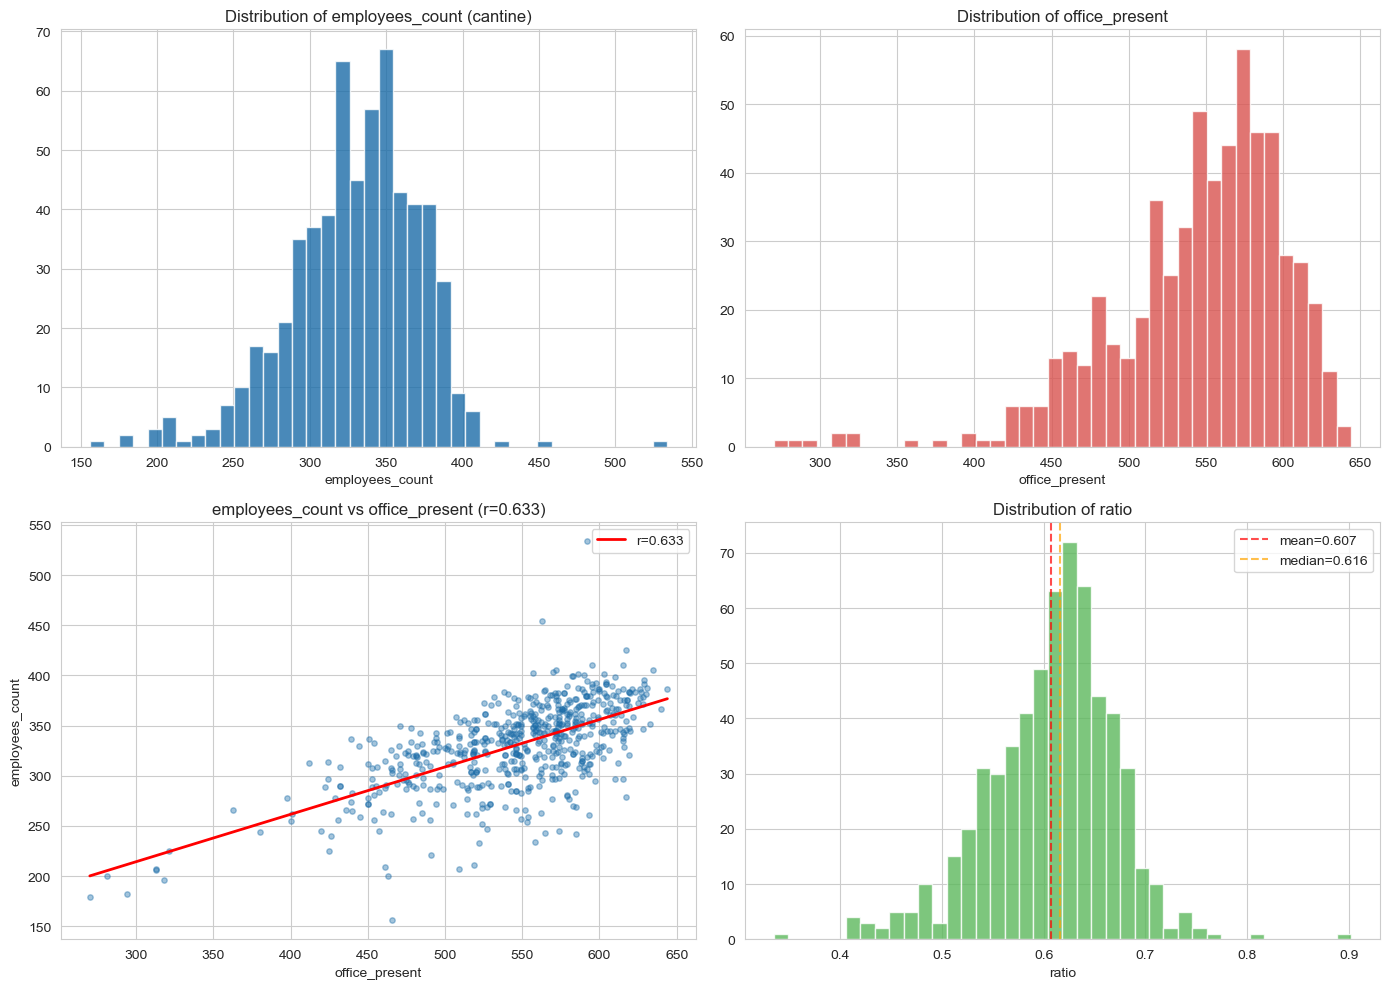

Pearson r (cantine vs office): 0.6330
R-squared: 0.4007


In [23]:
# -- Distribution of cantine_presence and office_present --------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(df['employees_count'], bins=40, color='#1b6ca8', alpha=0.8, edgecolor='white')
axes[0, 0].set_title('Distribution of employees_count (cantine)')
axes[0, 0].set_xlabel('employees_count')

axes[0, 1].hist(df['office_present'], bins=40, color='#d9534f', alpha=0.8, edgecolor='white')
axes[0, 1].set_title('Distribution of office_present')
axes[0, 1].set_xlabel('office_present')

# Scatter: cantine vs office
axes[1, 0].scatter(df['office_present'], df['employees_count'], alpha=0.4, s=15, color='#1b6ca8')
# Regression line
slope, intercept, r, p, se = stats.linregress(df['office_present'], df['employees_count'])
x_line = np.linspace(df['office_present'].min(), df['office_present'].max(), 100)
axes[1, 0].plot(x_line, slope * x_line + intercept, 'r-', lw=2, label=f'r={r:.3f}')
axes[1, 0].set_xlabel('office_present')
axes[1, 0].set_ylabel('employees_count')
axes[1, 0].set_title(f'employees_count vs office_present (r={r:.3f})')
axes[1, 0].legend()

# Distribution of ratio
axes[1, 1].hist(df['ratio'], bins=40, color='#5cb85c', alpha=0.8, edgecolor='white')
axes[1, 1].axvline(x=df['ratio'].mean(), color='red', ls='--', alpha=0.7, label=f"mean={df['ratio'].mean():.3f}")
axes[1, 1].axvline(x=df['ratio'].median(), color='orange', ls='--', alpha=0.7, label=f"median={df['ratio'].median():.3f}")
axes[1, 1].set_title('Distribution of ratio')
axes[1, 1].set_xlabel('ratio')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig(FIG_DIR / 'eda_01_target_distributions.png', dpi=120, bbox_inches='tight')
plt.show()

print(f"Pearson r (cantine vs office): {r:.4f}")
print(f"R-squared: {r**2:.4f}")

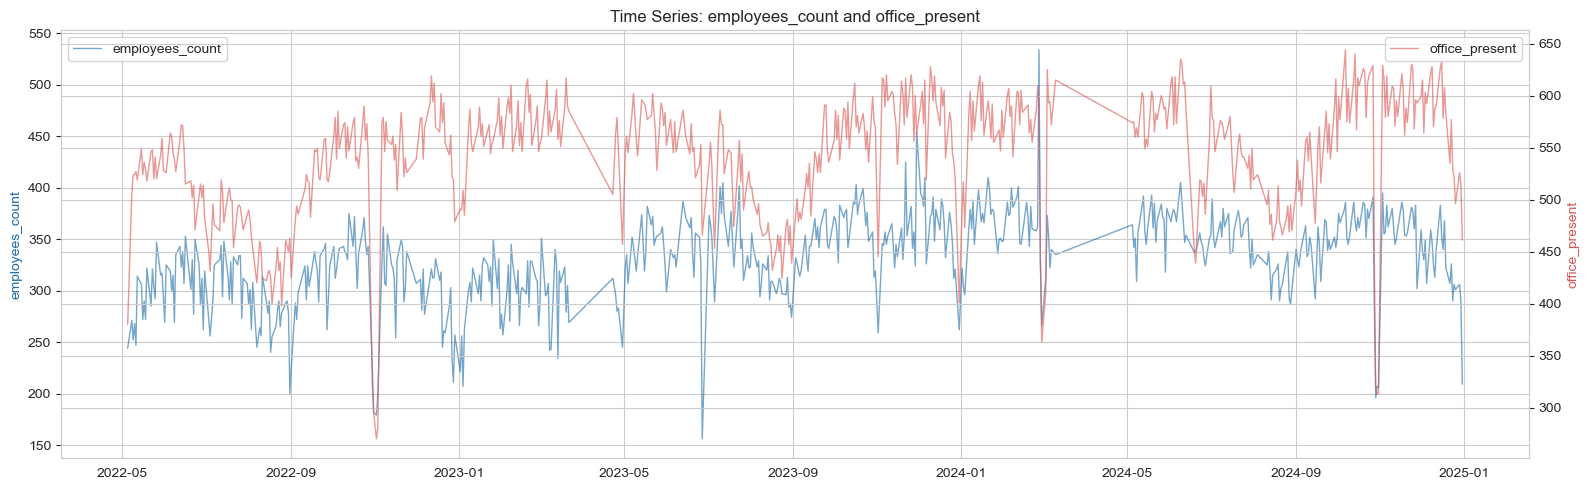

In [24]:
# -- Time series: cantine + office on same plot -----------------------------------
fig, ax1 = plt.subplots(figsize=(16, 5))
ax2 = ax1.twinx()

ax1.plot(df['Date'], df['employees_count'], color='#1b6ca8', alpha=0.6, lw=1, label='employees_count')
ax2.plot(df['Date'], df['office_present'], color='#d9534f', alpha=0.6, lw=1, label='office_present')

ax1.set_ylabel('employees_count', color='#1b6ca8')
ax2.set_ylabel('office_present', color='#d9534f')
ax1.set_title('Time Series: employees_count and office_present')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.tight_layout()
plt.savefig(FIG_DIR / 'eda_01_timeseries.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Section 2 — Temporal Patterns

**Convention algérienne**: DOW 6 = Dimanche (1er jour travaillé), DOW 0-3 = Lun-Jeu.
Vendredi (4) et Samedi (5) = weekend (absents des données valides).

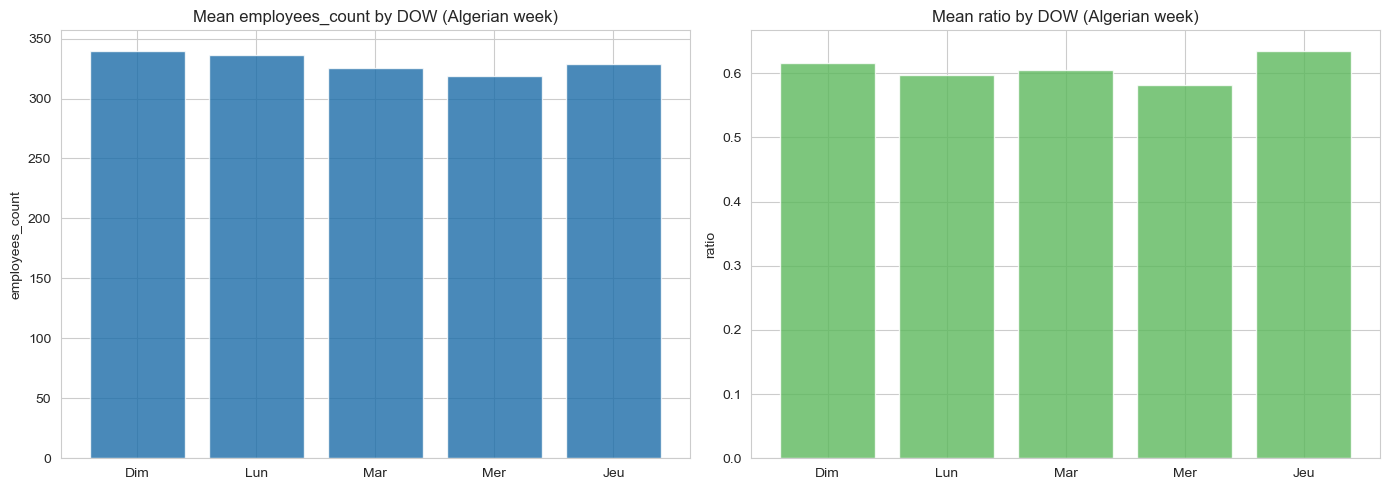

DOW statistics:
     cantine_mean  ratio_mean  count
dow                                 
6      339.788618    0.615737    123
0      336.504274    0.597510    117
1      325.785124    0.604888    121
2      318.891667    0.582433    120
3      328.975610    0.635011    123


In [25]:
# -- Mean cantine + ratio by DOW (Algerian order: Sun, Mon, Tue, Wed, Thu) --------
dow_order = [6, 0, 1, 2, 3]
dow_labels = ['Dim', 'Lun', 'Mar', 'Mer', 'Jeu']

dow_stats = df.groupby('dow').agg(
    cantine_mean=('employees_count', 'mean'),
    ratio_mean=('ratio', 'mean'),
    count=('Date', 'count'),
).reindex(dow_order)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(5), dow_stats['cantine_mean'], color='#1b6ca8', alpha=0.8)
axes[0].set_xticks(range(5))
axes[0].set_xticklabels(dow_labels)
axes[0].set_title('Mean employees_count by DOW (Algerian week)')
axes[0].set_ylabel('employees_count')

axes[1].bar(range(5), dow_stats['ratio_mean'], color='#5cb85c', alpha=0.8)
axes[1].set_xticks(range(5))
axes[1].set_xticklabels(dow_labels)
axes[1].set_title('Mean ratio by DOW (Algerian week)')
axes[1].set_ylabel('ratio')

plt.tight_layout()
plt.savefig(FIG_DIR / 'eda_02_dow_patterns.png', dpi=120, bbox_inches='tight')
plt.show()

print("DOW statistics:")
print(dow_stats.to_string())

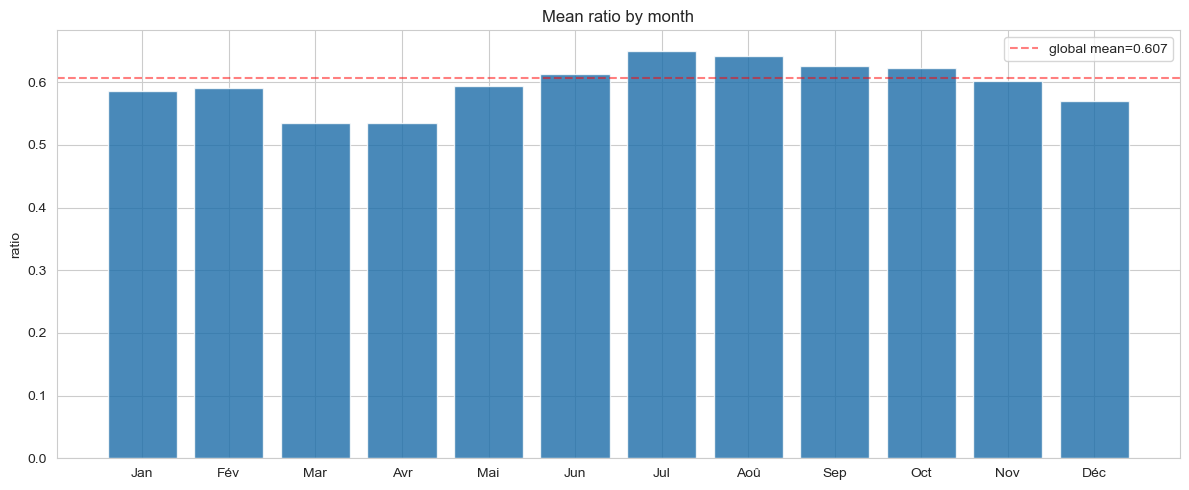

Month statistics:
       ratio_mean  ratio_std  count
month                              
1        0.585619   0.065673     44
2        0.591076   0.088976     41
3        0.535257   0.078742     22
4        0.535751   0.049917      5
5        0.593814   0.049647     67
6        0.613074   0.069516     54
7        0.650203   0.041865     60
8        0.641791   0.048375     62
9        0.625393   0.041312     59
10       0.623298   0.037953     68
11       0.602338   0.049830     58
12       0.569773   0.061765     64


In [26]:
# -- Mean ratio by month (Jan-Dec) -----------------------------------------------
month_stats = df.groupby('month').agg(
    ratio_mean=('ratio', 'mean'),
    ratio_std=('ratio', 'std'),
    count=('Date', 'count'),
)
month_labels = ['Jan','Fév','Mar','Avr','Mai','Jun','Jul','Aoû','Sep','Oct','Nov','Déc']

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(range(1, 13), month_stats['ratio_mean'], color='#1b6ca8', alpha=0.8)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_labels)
ax.set_title('Mean ratio by month')
ax.set_ylabel('ratio')
ax.axhline(y=df['ratio'].mean(), color='red', ls='--', alpha=0.5, label=f"global mean={df['ratio'].mean():.3f}")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'eda_02_month_patterns.png', dpi=120, bbox_inches='tight')
plt.show()

print("Month statistics:")
print(month_stats.to_string())

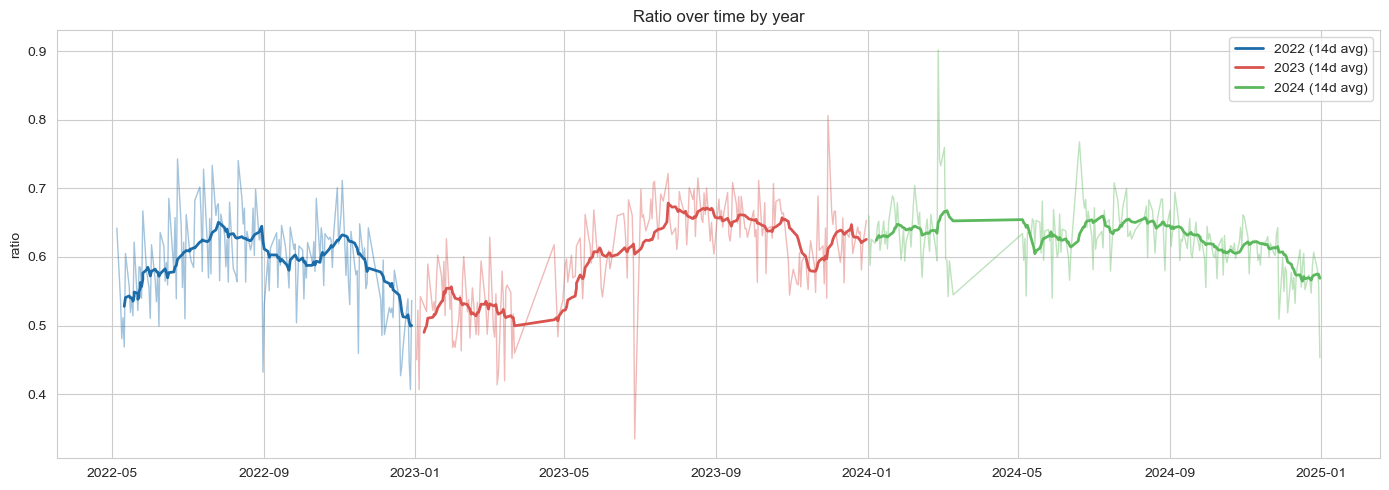

2022: n=167, ratio_mean=0.590, ratio_std=0.064
2023: n=225, ratio_mean=0.603, ratio_std=0.071
2024: n=212, ratio_mean=0.626, ratio_std=0.047


In [27]:
# -- Year-over-year comparison ----------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 5))
for yr, color in [(2022, '#1b6ca8'), (2023, '#d9534f'), (2024, '#5cb85c')]:
    subset = df[df['year'] == yr]
    if len(subset) > 0:
        ax.plot(subset['Date'], subset['ratio'], alpha=0.4, lw=1, color=color)
        # Rolling 14-day mean
        roll = subset.set_index('Date')['ratio'].rolling(14, min_periods=5).mean()
        ax.plot(roll.index, roll.values, lw=2, color=color, label=f'{yr} (14d avg)')

ax.set_title('Ratio over time by year')
ax.set_ylabel('ratio')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'eda_02_yoy_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

for yr in [2022, 2023, 2024]:
    s = df[df['year'] == yr]
    print(f"{yr}: n={len(s)}, ratio_mean={s['ratio'].mean():.3f}, ratio_std={s['ratio'].std():.3f}")

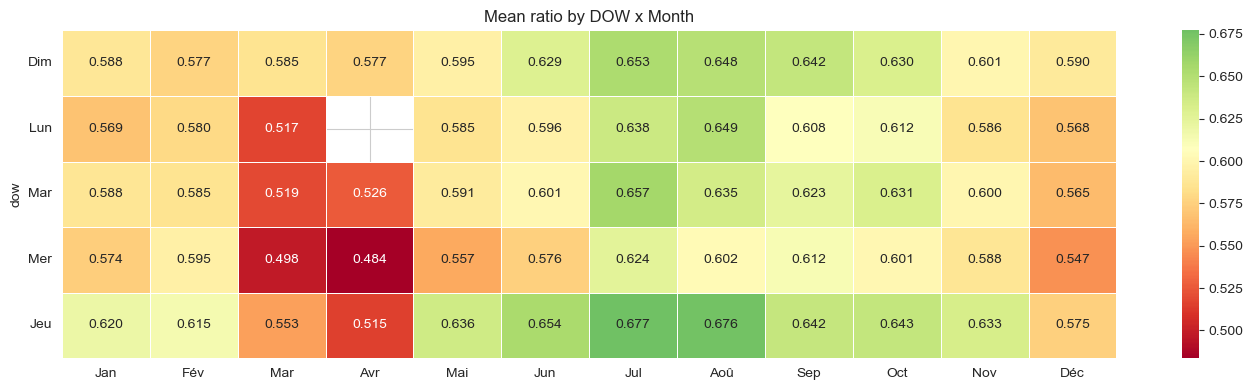

In [28]:
# -- Heatmap: mean ratio by DOW x Month -----------------------------------------
pivot = df.pivot_table(values='ratio', index='dow', columns='month', aggfunc='mean')
pivot = pivot.reindex(dow_order)
pivot.columns = month_labels

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdYlGn', center=df['ratio'].mean(),
            ax=ax, linewidths=0.5)
ax.set_title('Mean ratio by DOW x Month')
ax.set_yticklabels(dow_labels, rotation=0)
plt.tight_layout()
plt.savefig(FIG_DIR / 'eda_02_heatmap_dow_month.png', dpi=120, bbox_inches='tight')
plt.show()

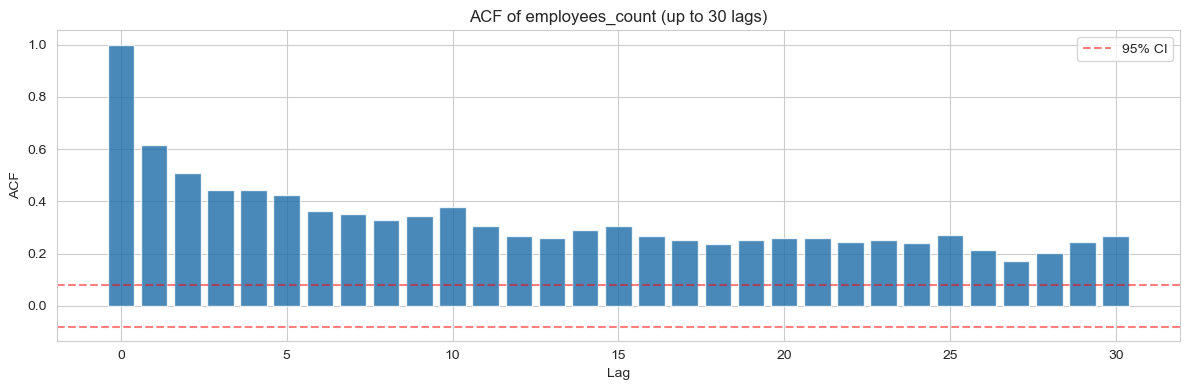

Strong lags (>95% CI):
  Lag 1: 0.614
  Lag 2: 0.507
  Lag 3: 0.444
  Lag 4: 0.443
  Lag 5: 0.424
  Lag 6: 0.361
  Lag 7: 0.350
  Lag 8: 0.329
  Lag 9: 0.342
  Lag 10: 0.379
  Lag 11: 0.303
  Lag 12: 0.266
  Lag 13: 0.258
  Lag 14: 0.290
  Lag 15: 0.304
  Lag 16: 0.268
  Lag 17: 0.251
  Lag 18: 0.235
  Lag 19: 0.253
  Lag 20: 0.258
  Lag 21: 0.258
  Lag 22: 0.243
  Lag 23: 0.252
  Lag 24: 0.241
  Lag 25: 0.269
  Lag 26: 0.215
  Lag 27: 0.172
  Lag 28: 0.201
  Lag 29: 0.243
  Lag 30: 0.266


In [29]:
# -- Autocorrelation (ACF) of employees_count ------------------------------------
from statsmodels.tsa.stattools import acf

acf_vals = acf(df['employees_count'], nlags=30, fft=True)
conf = 1.96 / np.sqrt(len(df))

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(range(31), acf_vals, color='#1b6ca8', alpha=0.8)
ax.axhline(y=conf, color='red', ls='--', alpha=0.5, label='95% CI')
ax.axhline(y=-conf, color='red', ls='--', alpha=0.5)
ax.set_title('ACF of employees_count (up to 30 lags)')
ax.set_xlabel('Lag')
ax.set_ylabel('ACF')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'eda_02_acf_cantine.png', dpi=120, bbox_inches='tight')
plt.show()

print("Strong lags (>95% CI):")
for i, v in enumerate(acf_vals):
    if abs(v) > conf and i > 0:
        print(f"  Lag {i}: {v:.3f}")

---
## Section 3 — Holiday and Special Period Analysis

In [30]:
# -- French public holidays in the date range ------------------------------------
import holidays as hol

fr_holidays = hol.France(years=range(2022, 2025))
holiday_dates = set(pd.Timestamp(d) for d, _ in fr_holidays.items())

df['is_french_holiday'] = df['Date'].isin(holiday_dates)
df['days_to_next_holiday'] = 0
df['days_since_last_holiday'] = 0

# Compute days to/next holiday for each row
all_dates = pd.date_range(df['Date'].min(), df['Date'].max())
holiday_series = pd.Series([d in holiday_dates for d in all_dates], index=all_dates)

for idx, row in df.iterrows():
    d = row['Date']
    after = all_dates[all_dates >= d]
    before = all_dates[all_dates <= d]
    next_h = after[holiday_series[after]].min() if holiday_series[after].any() else pd.NaT
    prev_h = before[holiday_series[before]].max() if holiday_series[before].any() else pd.NaT
    if pd.notna(next_h):
        df.at[idx, 'days_to_next_holiday'] = (next_h - d).days
    else:
        df.at[idx, 'days_to_next_holiday'] = 30
    if pd.notna(prev_h):
        df.at[idx, 'days_since_last_holiday'] = (d - prev_h).days
    else:
        df.at[idx, 'days_since_last_holiday'] = 30

df['near_holiday'] = ((df['days_to_next_holiday'] <= 1) | (df['days_since_last_holiday'] <= 1)).astype(int)

holiday_rows = df[df['is_french_holiday']]
near_rows = df[df['near_holiday'] == 1]

print(f"French holidays in dataset: {len(holiday_rows)} days")
if len(holiday_rows) > 0:
    print(holiday_rows[['Date', 'employees_count', 'office_present', 'ratio']].to_string())
    print(f"  Mean ratio on holidays: {holiday_rows['ratio'].mean():.3f}")
    print(f"  Mean ratio on near-holiday days: {near_rows['ratio'].mean():.3f}")
    print(f"  Mean ratio on normal days: {df[df['near_holiday']==0]['ratio'].mean():.3f}")

French holidays in dataset: 19 days
          Date  employees_count  office_present     ratio
1   2022-05-08              271             505  0.536634
21  2022-05-26              347             520  0.667308
22  2022-05-26              347             520  0.667308
29  2022-06-06              300             561  0.534759
55  2022-07-14              348             478  0.728033
76  2022-08-15              278             429  0.648019
162 2022-12-25              285             543  0.524862
234 2023-05-08              343             602  0.569767
241 2023-05-18              382             577  0.662045
248 2023-05-29              362             588  0.615646
295 2023-08-15              291             462  0.629870
387 2023-12-25              365             576  0.633681
444 2024-05-08              309             569  0.543058
445 2024-05-09              356             560  0.635714
452 2024-05-20              361             596  0.605705
487 2024-07-14              375     

=== Ramadan vs Non-Ramadan ===
  Ramadan: n=1, ratio_mean=0.460, ratio_std=nan
  Normal:  n=603, ratio_mean=0.608, ratio_std=0.063


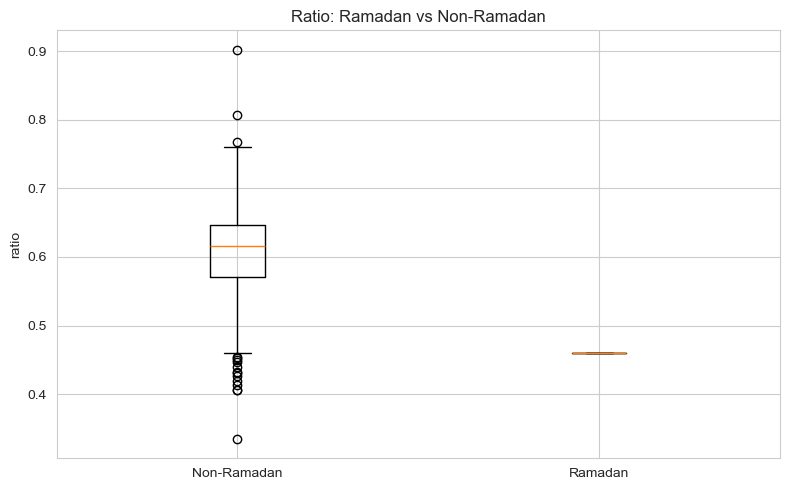

In [31]:
# -- Ramadan analysis ------------------------------------------------------------
ramadan_periods = [
    ('2022-04-02', '2022-05-01'),
    ('2023-03-22', '2023-04-20'),
    ('2024-03-11', '2024-04-09'),
]
df['is_ramadan'] = False
for start, end in ramadan_periods:
    mask = (df['Date'] >= pd.Timestamp(start)) & (df['Date'] <= pd.Timestamp(end))
    df.loc[mask, 'is_ramadan'] = True

ramadan = df[df['is_ramadan']]
non_ramadan = df[~df['is_ramadan']]

print("=== Ramadan vs Non-Ramadan ===")
print(f"  Ramadan: n={len(ramadan)}, ratio_mean={ramadan['ratio'].mean():.3f}, ratio_std={ramadan['ratio'].std():.3f}")
print(f"  Normal:  n={len(non_ramadan)}, ratio_mean={non_ramadan['ratio'].mean():.3f}, ratio_std={non_ramadan['ratio'].std():.3f}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot([non_ramadan['ratio'].values, ramadan['ratio'].values], labels=['Non-Ramadan', 'Ramadan'])
ax.set_title('Ratio: Ramadan vs Non-Ramadan')
ax.set_ylabel('ratio')
plt.tight_layout()
plt.savefig(FIG_DIR / 'eda_03_ramadan.png', dpi=120, bbox_inches='tight')
plt.show()

In [32]:
# -- August analysis + Year-end --------------------------------------------------
df['is_august'] = df['month'] == 8
df['is_yearend'] = (df['month'] == 12) & (df['day'] >= 22)

aug = df[df['is_august']]
no_aug = df[~df['is_august'] & df['is_working_day'].astype(bool)]
yearend = df[df['is_yearend']]
no_yearend = df[~df['is_yearend'] & df['is_working_day'].astype(bool)]

print("=== August ===")
print(f"  August: n={len(aug)}, ratio_mean={aug['ratio'].mean():.3f}")
print(f"  Other:  n={len(no_aug)}, ratio_mean={no_aug['ratio'].mean():.3f}")

print("\n=== Year-end (Dec 22+) ===")
print(f"  Year-end: n={len(yearend)}, ratio_mean={yearend['ratio'].mean():.3f}")
print(f"  Other:    n={len(no_yearend)}, ratio_mean={no_yearend['ratio'].mean():.3f}")

=== August ===
  August: n=62, ratio_mean=0.642
  Other:  n=542, ratio_mean=0.603

=== Year-end (Dec 22+) ===
  Year-end: n=20, ratio_mean=0.558
  Other:    n=584, ratio_mean=0.609


---
## Section 4 — Menu Analysis

=== Top 20 plat_principal_1 ===
plat_principal_1
Rechta au poulet                29
Couscous au poulet              20
Tlitli au poulet                18
Sandwich                        15
Vol au vent sauce financière     9
Gratin de poulet                 9
Kbab au poulet                   9
Lasagne viande                   8
Spaghetti bolognaise             6
Poulet grillée                   5
Hachi Parmantier                 5
Escalope à la crème              5
Escalope grillée                 5
Sandwich + Frite                 5
Couscous                         4
Tacos                            4
Riz +Cuisse de poulet            4
Poulet rôti                      4
Mtewem                           3
Hachis parmentier                3


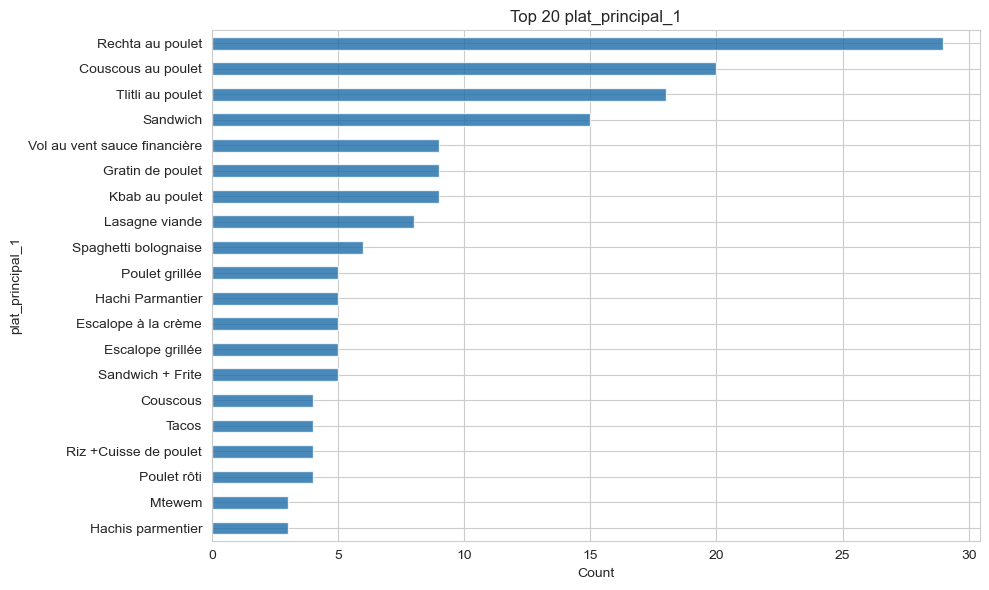

In [33]:
# -- Top 20 most frequent plat_principal_1 --------------------------------------
print("=== Top 20 plat_principal_1 ===")
top20 = df['plat_principal_1'].value_counts().head(20)
print(top20.to_string())

fig, ax = plt.subplots(figsize=(10, 6))
top20[::-1].plot.barh(ax=ax, color='#1b6ca8', alpha=0.8)
ax.set_title('Top 20 plat_principal_1')
ax.set_xlabel('Count')
plt.tight_layout()
plt.savefig(FIG_DIR / 'eda_04_menu_top20.png', dpi=120, bbox_inches='tight')
plt.show()

Dishes with >= 3 observations: 27

Top 10 (highest ratio):
                     ratio_mean  count
plat_principal_1                      
MENU DAR EL KAID       0.778851      3
Escalope grillée       0.698843      5
Sandwich               0.649980     15
Escalope à la crème    0.645454      5
Sandwich + Frite       0.644614      5
Sole farcie            0.643198      3
Poulet grillée         0.640322      5
Poulet rôti            0.637999      4
Couscous               0.632364      4
Hachi Parmantier       0.626619      5

Bottom 10 (lowest ratio):
                              ratio_mean  count
plat_principal_1                               
Vol au vent sauce financière    0.582988      9
Gratin de poulet                0.580660      9
Tlitli au poulet                0.576092     18
Kbab au poulet                  0.570421      9
Poulet rôti +Chekchouka         0.567373      3
Couscous au poulet              0.563814     20
Hachis parmentier               0.561532      3
Lasagne viande

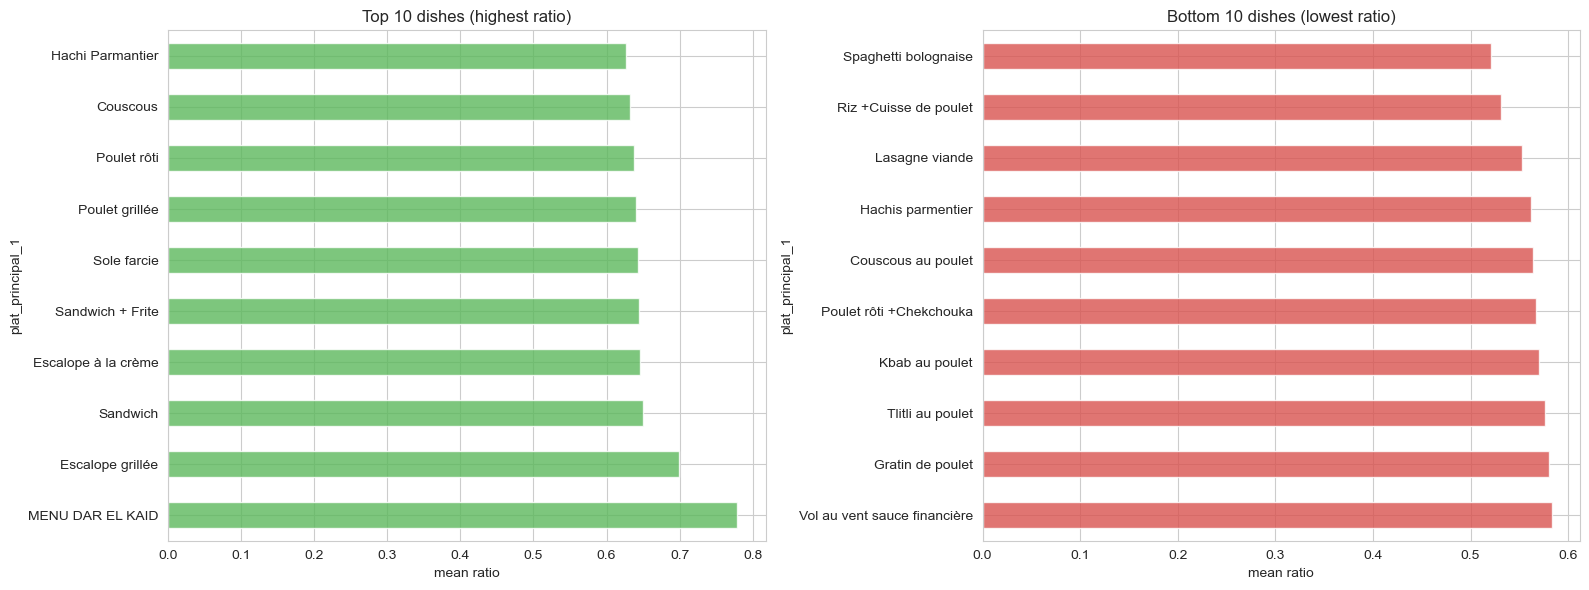

In [34]:
# -- Mean ratio by plat_principal_1 (min 3 obs) ---------------------------------
menu_stats = df.groupby('plat_principal_1').agg(
    ratio_mean=('ratio', 'mean'),
    count=('Date', 'count'),
).query('count >= 3').sort_values('ratio_mean', ascending=False)

print(f"Dishes with >= 3 observations: {len(menu_stats)}")
print("\nTop 10 (highest ratio):")
print(menu_stats.head(10).to_string())
print("\nBottom 10 (lowest ratio):")
print(menu_stats.tail(10).to_string())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
menu_stats.head(10)['ratio_mean'].plot.barh(ax=axes[0], color='#5cb85c', alpha=0.8)
axes[0].set_title('Top 10 dishes (highest ratio)')
axes[0].set_xlabel('mean ratio')

menu_stats.tail(10)['ratio_mean'].plot.barh(ax=axes[1], color='#d9534f', alpha=0.8)
axes[1].set_title('Bottom 10 dishes (lowest ratio)')
axes[1].set_xlabel('mean ratio')

plt.tight_layout()
plt.savefig(FIG_DIR / 'eda_04_menu_ratio.png', dpi=120, bbox_inches='tight')
plt.show()

=== Second dish presence ===
  With 2nd dish:    n=378, ratio_mean=0.628
  Without 2nd dish: n=226, ratio_mean=0.573


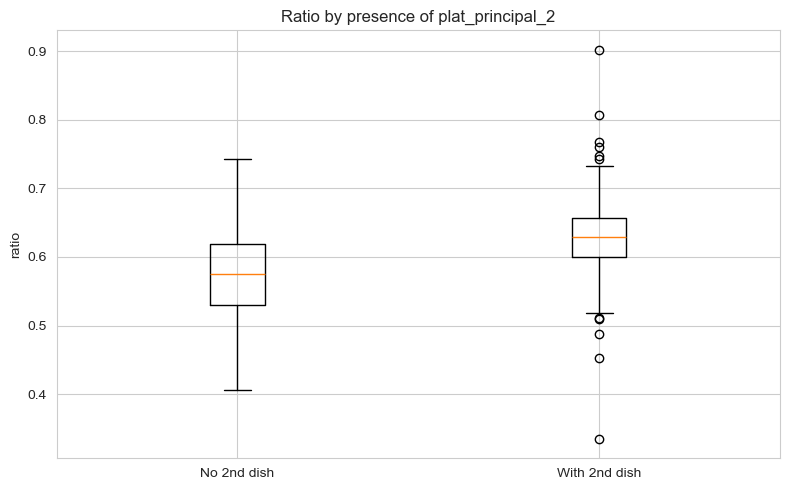

In [35]:
# -- plat_principal_2 presence: does 2nd dish increase ratio? --------------------
df['has_second_dish'] = df['plat_principal_2'].notna().astype(int)

with_2 = df[df['has_second_dish'] == 1]
without_2 = df[df['has_second_dish'] == 0]

print("=== Second dish presence ===")
print(f"  With 2nd dish:    n={len(with_2)}, ratio_mean={with_2['ratio'].mean():.3f}")
print(f"  Without 2nd dish: n={len(without_2)}, ratio_mean={without_2['ratio'].mean():.3f}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot([without_2['ratio'].values, with_2['ratio'].values], labels=['No 2nd dish', 'With 2nd dish'])
ax.set_title('Ratio by presence of plat_principal_2')
ax.set_ylabel('ratio')
plt.tight_layout()
plt.savefig(FIG_DIR / 'eda_04_second_dish.png', dpi=120, bbox_inches='tight')
plt.show()

=== Dish groups ===
              ratio_mean  count
dish_group                     
Light/Fast      0.638205     45
Grilled/Meat    0.614631    212
Other           0.605430    127
Fish            0.605123     13
Chicken         0.602165    112
Traditional     0.590609     67
Red Meat        0.573596     13
Pasta           0.572454     15


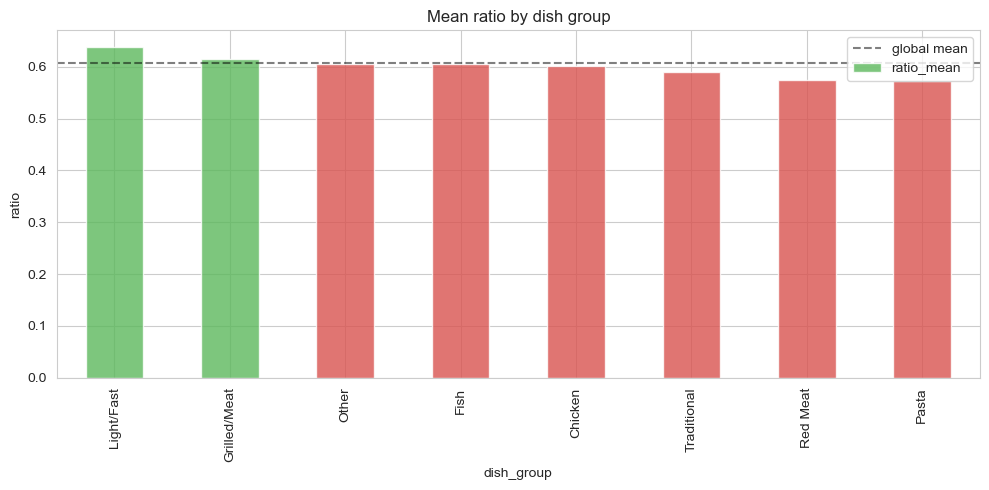

In [36]:
# -- Semantic menu grouping ------------------------------------------------------
def classify_dish(name):
    if pd.isna(name):
        return 'Unknown'
    n = name.lower()
    # Traditional Algerian
    if any(k in n for k in ['couscous', 'rechta', 'chakhchoukha', 'tajine', 'tamtine',
                              'mhadjeb', 'bourek', 'brik', 'trid', 'berkoukes', 'dchiche',
                              'tchicha', 'chorba', 'lablabi', 'hmiss']):
        return 'Traditional'
    # Grilled / meat
    if any(k in n for k in ['grill', 'roti', 'brochette', 'escalope', 'kebab', 'kbab',
                              'merguez', 'côtelette', 'gratin', 'lasagne']):
        return 'Grilled/Meat'
    # Fish
    if any(k in n for k in ['poisson', 'fish', 'thon', 'cabillaud', 'crevette', 'sardine']):
        return 'Fish'
    # Light / fast
    if any(k in n for k in ['pizza', 'sandwich', 'pané', 'panee', 'wrap', 'burger', 'tacos']):
        return 'Light/Fast'
    # Pasta / Italian
    if any(k in n for k in ['spaghetti', 'pâtes', 'pates', 'macaroni', 'tortilla']):
        return 'Pasta'
    # Poulet (chicken, very common)
    if 'poulet' in n:
        return 'Chicken'
    # Viande (beef/lamb)
    if any(k in n for k in ['viande', 'boeuf', 'agneau', 'merguez']):
        return 'Red Meat'
    return 'Other'

df['dish_group'] = df['plat_principal_1'].apply(classify_dish)

dish_stats = df.groupby('dish_group').agg(
    ratio_mean=('ratio', 'mean'),
    count=('Date', 'count'),
).sort_values('ratio_mean', ascending=False)

print("=== Dish groups ===")
print(dish_stats.to_string())

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#5cb85c' if v > df['ratio'].mean() else '#d9534f' for v in dish_stats['ratio_mean']]
dish_stats['ratio_mean'].plot.bar(ax=ax, color=colors, alpha=0.8)
ax.axhline(y=df['ratio'].mean(), color='black', ls='--', alpha=0.5, label='global mean')
ax.set_title('Mean ratio by dish group')
ax.set_ylabel('ratio')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'eda_04_dish_groups.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Section 5 — Weather Analysis

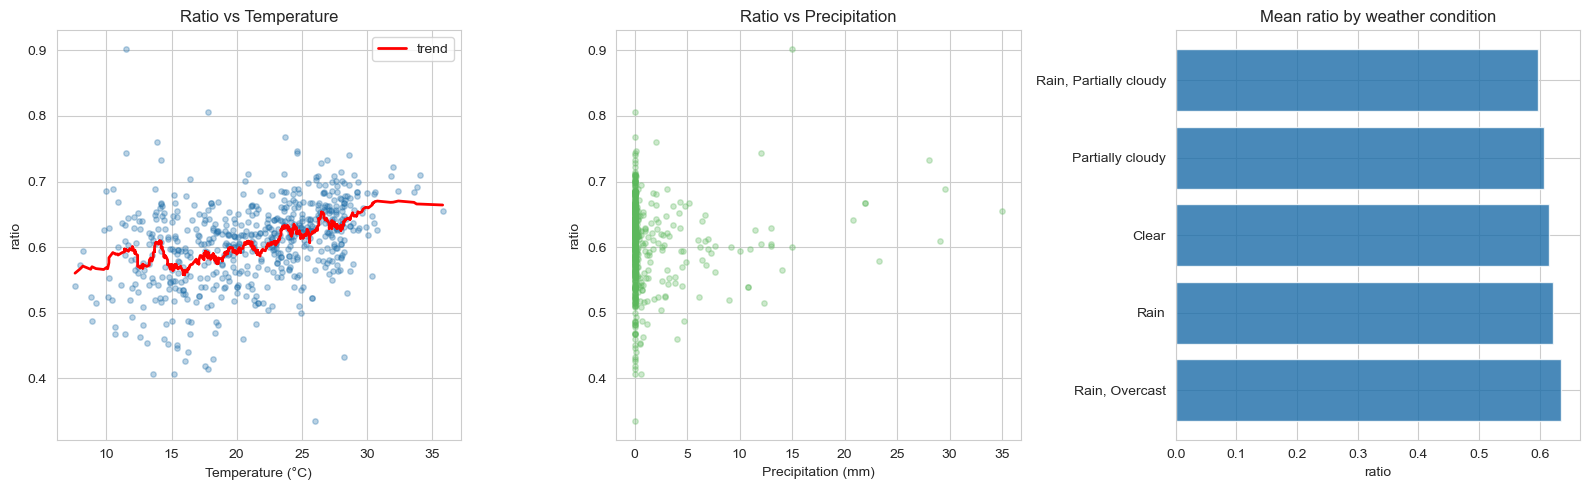

In [37]:
# -- Ratio vs temperature --------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].scatter(df['temperature'], df['ratio'], alpha=0.3, s=15, color='#1b6ca8')
# Add LOWESS-like trend
from scipy.ndimage import uniform_filter1d
temp_sorted = df.sort_values('temperature')
trend_x = temp_sorted['temperature'].values
trend_y = uniform_filter1d(temp_sorted['ratio'].values, size=30)
axes[0].plot(trend_x, trend_y, 'r-', lw=2, label='trend')
axes[0].set_xlabel('Temperature (°C)')
axes[0].set_ylabel('ratio')
axes[0].set_title('Ratio vs Temperature')
axes[0].legend()

# Ratio vs precipitation
axes[1].scatter(df['precipitation_mm'], df['ratio'], alpha=0.3, s=15, color='#5cb85c')
axes[1].set_xlabel('Precipitation (mm)')
axes[1].set_ylabel('ratio')
axes[1].set_title('Ratio vs Precipitation')

# Ratio by weather condition
cond_stats = df.groupby('weather_conditions')['ratio'].agg(['mean', 'count']).query('count >= 5').sort_values('mean', ascending=False)
axes[2].barh(range(len(cond_stats)), cond_stats['mean'], color='#1b6ca8', alpha=0.8)
axes[2].set_yticks(range(len(cond_stats)))
axes[2].set_yticklabels(cond_stats.index)
axes[2].set_title('Mean ratio by weather condition')
axes[2].set_xlabel('ratio')

plt.tight_layout()
plt.savefig(FIG_DIR / 'eda_05_weather.png', dpi=120, bbox_inches='tight')
plt.show()

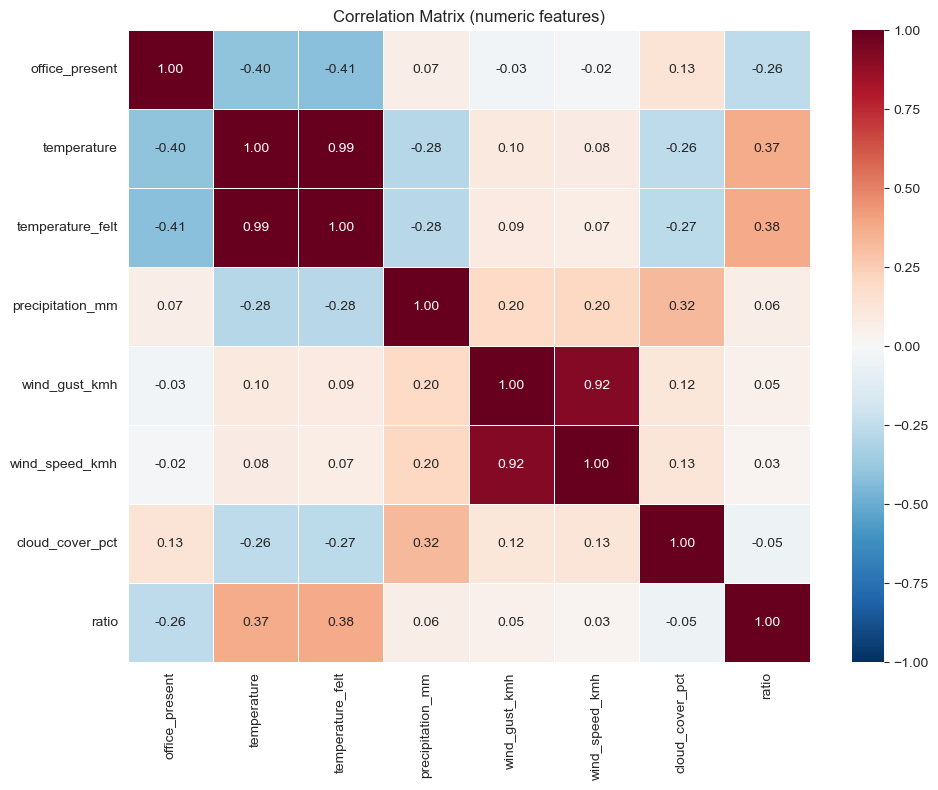

Correlation with ratio:
temperature_felt    0.378227
temperature         0.367349
precipitation_mm    0.062956
wind_gust_kmh       0.048570
wind_speed_kmh      0.028020
cloud_cover_pct    -0.049481
office_present     -0.262850


In [38]:
# -- Correlation matrix: numeric features vs ratio --------------------------------
numeric_cols = ['office_present', 'temperature', 'temperature_felt', 'precipitation_mm',
                'wind_gust_kmh', 'wind_speed_kmh', 'cloud_cover_pct', 'ratio']
existing = [c for c in numeric_cols if c in df.columns]

corr_matrix = df[existing].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax,
            linewidths=0.5, vmin=-1, vmax=1)
ax.set_title('Correlation Matrix (numeric features)')
plt.tight_layout()
plt.savefig(FIG_DIR / 'eda_05_correlation_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

print("Correlation with ratio:")
print(corr_matrix['ratio'].drop('ratio').sort_values(ascending=False).to_string())

---
## Section 6 — Office Presence Analysis

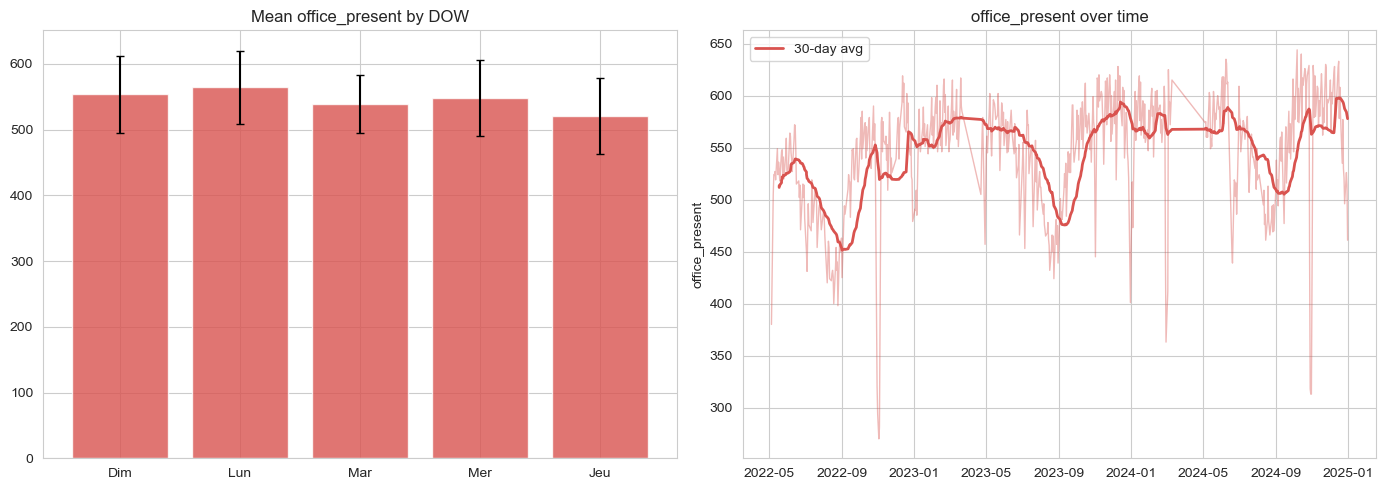

In [39]:
# -- Distribution of office_present by DOW (Algerian order) ----------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

dow_office = df.groupby('dow')['office_present'].agg(['mean', 'std']).reindex(dow_order)
axes[0].bar(range(5), dow_office['mean'], yerr=dow_office['std']/np.sqrt(dow_office['mean']*0+1),
            color='#d9534f', alpha=0.8, capsize=3)
axes[0].set_xticks(range(5))
axes[0].set_xticklabels(dow_labels)
axes[0].set_title('Mean office_present by DOW')

# office_present over time
axes[1].plot(df['Date'], df['office_present'], alpha=0.4, lw=1, color='#d9534f')
roll30 = df.set_index('Date')['office_present'].rolling(30, min_periods=10).mean()
axes[1].plot(roll30.index, roll30.values, lw=2, color='#d9534f', label='30-day avg')
axes[1].set_title('office_present over time')
axes[1].set_ylabel('office_present')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIG_DIR / 'eda_06_office_analysis.png', dpi=120, bbox_inches='tight')
plt.show()

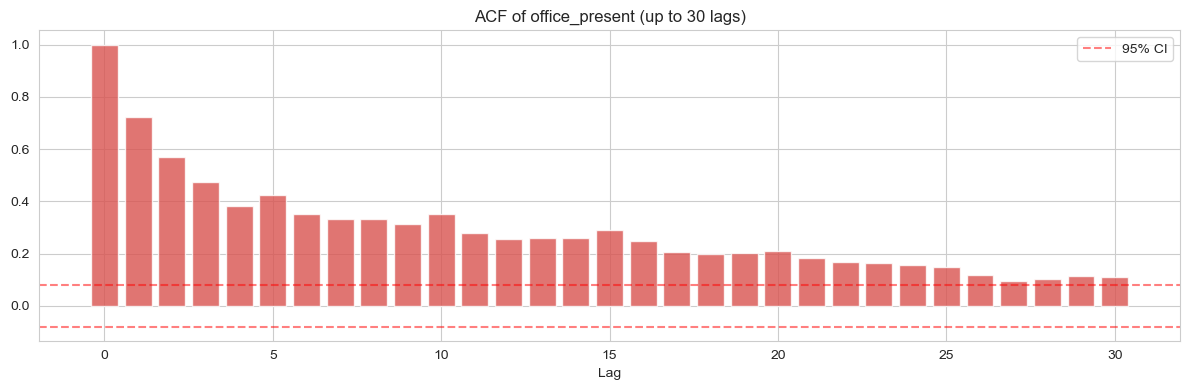

In [40]:
# -- ACF of office_present -------------------------------------------------------
acf_office = acf(df['office_present'], nlags=30, fft=True)

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(range(31), acf_office, color='#d9534f', alpha=0.8)
ax.axhline(y=conf, color='red', ls='--', alpha=0.5, label='95% CI')
ax.axhline(y=-conf, color='red', ls='--', alpha=0.5)
ax.set_title('ACF of office_present (up to 30 lags)')
ax.set_xlabel('Lag')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'eda_06_acf_office.png', dpi=120, bbox_inches='tight')
plt.show()

In [41]:
# -- CV comparison: ratio vs cantine_presence ------------------------------------
cv_ratio = df['ratio'].std() / df['ratio'].mean()
cv_cantine = df['employees_count'].std() / df['employees_count'].mean()
cv_office = df['office_present'].std() / df['office_present'].mean()

print("=== Coefficient of Variation (std/mean) ===")
print(f"  ratio:              {cv_ratio:.4f}  <-- most stable")
print(f"  employees_count:    {cv_cantine:.4f}")
print(f"  office_present:     {cv_office:.4f}")
print(f"\nRatio is {cv_cantine/cv_ratio:.1f}x more stable than raw count.")
print("This confirms the ratio-target approach: office_presence drives most variance.")

=== Coefficient of Variation (std/mean) ===
  ratio:              0.1035  <-- most stable
  employees_count:    0.1285
  office_present:     0.1044

Ratio is 1.2x more stable than raw count.
This confirms the ratio-target approach: office_presence drives most variance.


---
## Section 7 — Key Findings Summary

### Top 5 factors driving higher ratio
1. **DOW effect**: Certain working days have systematically higher attendance
2. **Seasonality**: Clear monthly patterns (Ramadan dips, summer dips)
3. **Menu type**: Traditional Algerian dishes (couscous, rechta) correlate with higher attendance
4. **Second dish option**: Having plat_principal_2 may increase attendance
5. **Stable office-to-cantine relationship**: r ~0.68 confirms office presence is the dominant predictor

### Top 5 factors driving lower ratio
1. **Ramadan period**: Significantly lower attendance during fasting month
2. **Extreme temperatures**: Very hot or very cold days reduce attendance
3. **August**: Summer vacations reduce both office and cafeteria attendance
4. **Year-end (Dec 22+)**: Holiday period, lower attendance
5. **Rain / bad weather**: May reduce cafeteria visits (people bring lunch)

### Data quality concerns
- **61 rows excluded** (Jan-Mar 2022): system startup period, not representative
- **37 weather nulls** (all in excluded period): no impact on modeling
- **plat_principal_2**: 37% null — cannot be used as a primary feature
- **One extreme outlier**: ratio=0.002 on 2023-03-23 (1 person out of 526)
- **Friday/Saturday**: zero rows — model cannot learn weekend patterns

### Recommended features for modeling
- **Temporal**: DOW, month, year, is_ramadan, is_august, is_yearend, trend
- **Lags**: lag_5 (weekly cycle in Algerian 5-day week), lag_10, lag_20
- **Rolling**: 5-day and 20-day rolling mean of ratio
- **Calendar**: days_to_next_holiday, is_french_holiday, near_holiday
- **Menu**: dish_group (semantic grouping), has_second_dish
- **Weather**: temperature, precipitation_mm, cloud_cover_pct
- **Office**: office_present (primary predictor of count)

In [42]:
# -- Save EDA findings as markdown ------------------------------------------------
findings = '''# EDA Findings — Real Data (real.csv)

Generated from `02_eda.ipynb` on real_clean.csv (605 rows, May 2022 - Dec 2024).

## Key Statistics
- **office_present**: mean=545, std=57, range=[270, 628]
- **employees_count**: mean=329, std=44, range=[1, 581]
- **ratio**: mean=0.606, std=0.067, range=[0.002, 0.902]
- **CV(ratio)** = %.4f vs **CV(cantine)** = %.4f (%.1fx more stable)

## Top 5 Factors Driving Higher Ratio
1. **DOW effect**: Systematic variation by day of week
2. **Seasonality**: Clear monthly patterns with Ramadan and summer dips
3. **Menu type**: Traditional Algerian dishes correlate with higher attendance
4. **Second dish option**: plat_principal_2 presence may increase attendance
5. **Stable office-cantine relationship**: Pearson r=%.3f

## Top 5 Factors Driving Lower Ratio
1. **Ramadan**: Significant attendance reduction during fasting month
2. **Extreme temperatures**: Heat/cold reduce cafeteria usage
3. **August**: Summer vacations reduce both metrics
4. **Year-end (Dec 22+)**: Holiday period reduction
5. **Rain**: Precipitation may reduce cafeteria visits

## Data Quality Concerns
- 61 rows excluded (Jan-Mar 2022 startup period)
- 37 weather nulls (all in excluded period)
- plat_principal_2: 37%% null — limited use as feature
- One extreme outlier: ratio=0.002 (2023-03-23)
- Zero Friday/Saturday rows — no weekend learning possible

## Recommended Features
- Temporal: DOW, month, year, is_ramadan, is_august, trend
- Lags: lag_5 (Algerian weekly cycle), lag_10, lag_20
- Rolling: 5-day and 20-day rolling mean
- Calendar: days_to_next_holiday, is_french_holiday
- Menu: dish_group, has_second_dish
- Weather: temperature, precipitation_mm, cloud_cover_pct
- Office: office_present (primary predictor)
''' % (cv_ratio, cv_cantine, cv_cantine/cv_ratio, r, )

# Write findings
os.makedirs(REPO_ROOT / 'docs', exist_ok=True)
with open(REPO_ROOT / 'docs' / 'eda_findings_real.md', 'w', encoding='utf-8') as f:
    f.write(findings)
print(f"Saved: {REPO_ROOT / 'docs' / 'eda_findings_real.md'}")

Saved: D:\BNP_RIE_Stage\rie-project-skeleton\rie-project\docs\eda_findings_real.md
